Imports & Configuration

In [ ]:
import re
import os
import math
import random
import json
from collections import Counter, defaultdict

DATA_DIR    = r"C:\Users\Dell\Desktop\data"   
MAX_CHARS   = 5_000_000                       
RANDOM_SEED = 42
#Backoff discount factor
LAMBDA      = 0.4

random.seed(RANDOM_SEED)

Load the Corpus from our folder

In [ ]:
SKIP_KEYWORDS = ('links_processed', 'DS_Store', 'amlignore', 'DS_store')


def load_corpus_from_folder(data_dir, max_chars=None):
    corpus_parts = []
    source_map   = defaultdict(int)
    total_chars  = 0

    for root, dirs, files in os.walk(data_dir):
        
        rel      = os.path.relpath(root, data_dir)       
        source   = rel.split(os.sep)[0]                   
        if source == '.':
            source = 'root'

        for fname in sorted(files):

            # Skip non-text files
            if not fname.endswith('.txt'):
                continue
            if any(kw in fname for kw in SKIP_KEYWORDS):
                continue

            fpath = os.path.join(root, fname)

            try:
                with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                    text = f.read()
            except Exception as e:
                print(f"Cannot read {fpath}: {e}")
                continue

            corpus_parts.append(text)
            source_map[source] += len(text)
            total_chars         += len(text)

            display = os.path.join(source, fname)
            print(f" {display:<55}  {len(text):>10,} chars")

            if max_chars and total_chars >= max_chars:
                print(f"\nReached char limit ({max_chars:,}), stopping")
                break

        if max_chars and total_chars >= max_chars:
            break

    raw_text = '\n'.join(corpus_parts)
    if max_chars:
        raw_text = raw_text[:max_chars]

    return raw_text, dict(source_map)


print("Loading corpus from folder...\n")
raw_text, source_map = load_corpus_from_folder(DATA_DIR, max_chars=MAX_CHARS)

print(f"\n{'─'*60}")
print(f"Corpus loaded!")
print(f"   Total characters : {len(raw_text):>12,}")
print(f"\nSource breakdown :")
for src, count in sorted(source_map.items(), key=lambda x: -x[1]):
    print(f"     {src:<22}  {count:>10,} chars")

Loading corpus from folder...

 darija-wiki\arywiki_articles_1.txt                           68,838 chars
 darija-wiki\arywiki_articles_2.txt                          159,992 chars
 darija-wiki\arywiki_articles_3.txt                          425,390 chars
 darija-wiki\arywiki_articles_4.txt                          882,581 chars
 darija-wiki\arywiki_articles_5.txt                          401,178 chars
 darija-wiki\arywiki_articles_6.txt                          467,108 chars
 darija-wiki\arywiki_articles_7.txt                          467,884 chars
 goud.ma\goud_articles_1.txt                                 108,582 chars
 goud.ma\goud_articles_2.txt                                 107,481 chars
 goud.ma\goud_articles_3.txt                                 162,136 chars
 goud.ma\goud_articles_4.txt                                 148,538 chars
 goud.ma\goud_articles_5.txt                                 148,128 chars
 goud.ma\goud_articles_6.txt                                 119,972 

Text Preprocessing

In [21]:
ARABIC_DIACRITICS = re.compile(r'[\u064B-\u065F\u0670]')

# Common Arabic punctuation marks
ARABIC_PUNCT = re.compile(
    r'[\u060C\u061B\u061F\u0640،؛؟!"#$%&\'()*+,\-/:;<=>?@\[\\\]^_`{|}~«»\u201C\u201D\u2018\u2019\u2026]'
)

ALEF_VARIANTS = re.compile(r'[\u0622\u0623\u0625\u0671]')

def preprocess_text(text):
    """
    Full cleaning pipeline for Darija text.
    Returns a cleaned string (NOT yet tokenized).
    """
    # 1. Remove URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 2. Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)

    text = re.sub(r'\[.*?\]', ' ', text)

    # 4. Remove Arabic diacritics
    text = ARABIC_DIACRITICS.sub('', text)

    # 5. Normalize Alef variants
    text = ALEF_VARIANTS.sub('ا', text)

    # 6. Remove Arabic punctuation
    text = ARABIC_PUNCT.sub(' ', text)
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # 8. Remove standalone numbers
    text = re.sub(r'\b\d+([.,]\d+)?\b', ' ', text)

    # 9. Lowercase Latin characters
    text = text.lower()

    # 10. Collapse any run of whitespace into a single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize(text, min_len=2):
    """
    Split cleaned text into word tokens.
    Drops tokens shorter than min_len (removes stray single characters).

    Example
    -------
    tokenize("كاينة ف إقليم")  →  ['كاينة', 'إقليم']
    (single 'ف' is dropped because len < 2)
    """
    return [t for t in text.split() if len(t) >= min_len]


print("Running preprocessing pipeline...")
print(f"   Input  : {len(raw_text):,} characters\n")

cleaned_text = preprocess_text(raw_text)
tokens       = tokenize(cleaned_text, min_len=2)

vocab      = set(tokens)
vocab_size = len(vocab)

print(f"   Output : {len(cleaned_text):,} characters  ({100*len(cleaned_text)/len(raw_text):.1f}% of original)")
print(f"   Tokens : {len(tokens):,}")
print(f"   Unique words (|V|) : {vocab_size:,}")

print(f"\nFirst 30 tokens:")
print(tokens[:30])

Running preprocessing pipeline...
   Input  : 5,000,000 characters

   Output : 4,425,171 characters  (88.5% of original)
   Tokens : 730,786
   Unique words (|V|) : 83,127

First 30 tokens:
['سيدي', 'بداج', 'جماعة', 'ترابية', 'قروية', 'كاينة', 'اقليم', 'الحوز', 'جهة', 'مراكش', 'اسفي', 'ساكنين', 'فيها', 'واحد', 'على', 'حسب', 'لاحصاء', 'لعام', 'تعليم', 'نسبة', 'لامية', 'ناس', 'لي', 'ما', 'كايعرفوش', 'يقراو', 'ولا', 'يكتبو', 'نسبة', 'سكان']


Build N-Gram Counts

In [ ]:
def build_ngrams(tokens, n):
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


#Unigrams
unigram_counts = Counter(tokens)
total_tokens   = sum(unigram_counts.values())   # N  (total token count)

#Bigrams
# C(w1, w2) for every consecutive pair
bigram_counts = Counter(build_ngrams(tokens, 2))

#Trigrams
trigram_counts = Counter(build_ngrams(tokens, 3))

#Summary
print(f"  N-gram Statistics:")
print(f"  Total tokens (N): {total_tokens:>12,}")
print(f"  Vocabulary size (|V|): {vocab_size:>12,}")
print(f"  Unique unigrams: {len(unigram_counts):>12,}")
print(f"  Unique bigrams: {len(bigram_counts):>12,}")
print(f"  Unique trigrams: {len(trigram_counts):>12,}")

  N-gram Statistics:
  Total tokens (N):      730,786
  Vocabulary size (|V|):       83,127
  Unique unigrams:       83,127
  Unique bigrams:      302,282
  Unique trigrams:      374,089


In [26]:
TOP_K = 15
def show_top_ngrams(counter, k=15, label=""):
    """Pretty-print the top-k N-grams with rank and count."""
    print(f"  Top {k}  {label}")
    print(f"  {'Rank':<5}  {'N-gram':<32}  {'Count':>8}")
    for rank, (ngram, count) in enumerate(counter.most_common(k), 1):
        text = ' '.join(ngram) if isinstance(ngram, tuple) else ngram
        print(f"  {rank:<5}  {text:<32}  {count:>8,}")


show_top_ngrams(unigram_counts, TOP_K, "UNIGRAMS  (single words)")
show_top_ngrams(bigram_counts,  TOP_K, "BIGRAMS   (word pairs)")
show_top_ngrams(trigram_counts, TOP_K, "TRIGRAMS  (word triples)")

  Top 15  UNIGRAMS  (single words)
  Rank   N-gram                               Count
  1      من                                  12,027
  2      في                                   9,651
  3      ديال                                 8,489
  4      على                                  8,060
  5      اللي                                 7,621
  6      لي                                   6,406
  7      نسبة                                 6,299
  8      ناس                                  4,595
  9      ما                                   4,259
  10     ان                                   3,620
  11     ولا                                  3,272
  12     فيها                                 2,338
  13     خدامين                               2,147
  14     هاد                                  2,141
  15     جهة                                  2,082
  Top 15  BIGRAMS   (word pairs)
  Rank   N-gram                               Count
  1      نسبة ناس                             2,

Raw Probabilities (No Smoothing)

In [29]:
def unigram_prob(word):
    """P(w) = C(w) / N"""
    return unigram_counts.get(word, 0) / total_tokens


def bigram_prob(w1, w2):
    """P(w2|w1) = C(w1,w2) / C(w1)"""
    c_uni = unigram_counts.get(w1, 0)
    if c_uni == 0:
        return 0.0
    return bigram_counts.get((w1, w2), 0) / c_uni


def trigram_prob(w1, w2, w3):
    """P(w3|w1,w2) = C(w1,w2,w3) / C(w1,w2)"""
    c_bi = bigram_counts.get((w1, w2), 0)
    if c_bi == 0:
        return 0.0
    return trigram_counts.get((w1, w2, w3), 0) / c_bi


#Ex calculations
print("Raw MLE Probability Examples")

top_words = [w for w, _ in unigram_counts.most_common(10)]
w1, w2, w3 = top_words[0], top_words[1], top_words[2]

print(f"\n  Words chosen from top-10: w1='{w1}'  w2='{w2}'  w3='{w3}'\n")

p_uni = unigram_prob(w1)
p_bi  = bigram_prob(w1, w2)
p_tri = trigram_prob(w1, w2, w3)

print(f"  P('{w1}')                   = {p_uni:.8f}")
print(f"  P('{w2}' | '{w1}')          = {p_bi:.8f}")
print(f"  P('{w3}' | '{w1}','{w2}') = {p_tri:.8f}")

# 0 problem
print("  0 Probability Demonstration:\n")
unseen = "__word_never_seen__"
p_zero_uni = unigram_prob(unseen)
p_zero_bi  = bigram_prob(w1, unseen)
p_zero_tri = trigram_prob(w1, w2, unseen)

print(f"  P('{unseen}')                = {p_zero_uni}")
print(f"  P('{unseen}' | '{w1}')       = {p_zero_bi}")
print(f"  P('{unseen}' | '{w1}','{w2}') = {p_zero_tri}")
print(f"\n All zero")
print(f"  One zero in a sentence")

Raw MLE Probability Examples

  Words chosen from top-10: w1='من'  w2='في'  w3='ديال'

  P('من')                   = 0.01645762
  P('في' | 'من')          = 0.00024944
  P('ديال' | 'من','في') = 0.00000000
  0 Probability Demonstration:

  P('__word_never_seen__')                = 0.0
  P('__word_never_seen__' | 'من')       = 0.0
  P('__word_never_seen__' | 'من','في') = 0.0

 All zero
  One zero in a sentence


Laplace Smoothing

In [ ]:
def unigram_prob_smooth(word):
    """
    Laplace-smoothed unigram
    P_smooth(w) = (C(w) + 1) / (N + |V|)
    """
    return (unigram_counts.get(word, 0) + 1) / (total_tokens + vocab_size)


def bigram_prob_smooth(w1, w2):
    """
    Laplace-smoothed bigram
    P_smooth(w2|w1) = (C(w1,w2) + 1) / (C(w1) + |V|)
    """
    c_bi  = bigram_counts.get((w1, w2), 0)
    c_uni = unigram_counts.get(w1, 0)
    return (c_bi + 1) / (c_uni + vocab_size)


def trigram_prob_smooth(w1, w2, w3):
    """
    Laplace-smoothed trigram
    P_smooth(w3|w1,w2) = (C(w1,w2,w3) + 1) / (C(w1,w2) + |V|)
    """
    c_tri = trigram_counts.get((w1, w2, w3), 0)
    c_bi  = bigram_counts.get((w1, w2), 0)
    return (c_tri + 1) / (c_bi + vocab_size)


#Before and After comparison table
print(f"  {'N-gram expression':<38} {'Raw':>12} {'Smoothed':>12}")

examples = [
    ("uni", w1),
    ("uni", "__unseen__"),
    ("bi",  (w1, w2)),
    ("bi",  (w1, "__unseen__")),
    ("tri", (w1, w2, w3)),
    ("tri", (w1, w2, "__unseen__")),
]

for kind, gram in examples:
    if kind == "uni":
        label = f"P('{gram}')"
        raw   = unigram_prob(gram)
        smo   = unigram_prob_smooth(gram)
    elif kind == "bi":
        a, b  = gram
        label = f"P('{b}' | '{a}')"
        raw   = bigram_prob(a, b)
        smo   = bigram_prob_smooth(a, b)
    else:
        a, b, c = gram
        label = f"P('{c}' | '{a}','{b}')"
        raw   = trigram_prob(a, b, c)
        smo   = trigram_prob_smooth(a, b, c)

    raw_str = f"{raw:.3e}" if raw > 0 else "0  ← ZERO!"
    smo_str = f"{smo:.3e}"
    print(f"  {label:<38} {raw_str:>12} {smo_str:>12}")

print(f"\n  Vocabulary |V| = {vocab_size:,}")
print(f"  Total tokens N = {total_tokens:,}")

  N-gram expression                               Raw     Smoothed
  P('من')                                   1.646e-02    1.478e-02
  P('__unseen__')                          0  ← ZERO!    1.229e-06
  P('في' | 'من')                            2.494e-04    4.204e-05
  P('__unseen__' | 'من')                   0  ← ZERO!    1.051e-05
  P('ديال' | 'من','في')                    0  ← ZERO!    1.203e-05
  P('__unseen__' | 'من','في')              0  ← ZERO!    1.203e-05

  Vocabulary |V| = 83,127
  Total tokens N = 730,786


Backoff Strategy

In [ ]:
def backoff_prob(w1, w2, w3, verbose=False):
    
    # Start with trigram
    if trigram_counts.get((w1, w2, w3), 0) > 0:
        p     = trigram_prob_smooth(w1, w2, w3)
        level = "trigram"

    # Back off to bigram
    elif bigram_counts.get((w2, w3), 0) > 0:
        p     = LAMBDA * bigram_prob_smooth(w2, w3)
        level = "bigram  (backed off once,  ×λ)"

    #unigram
    else:
        p     = LAMBDA**2 * unigram_prob_smooth(w3)
        level = "unigram (backed off twice, ×λ²)"

    if verbose:
        print(f"  P('{w3}' | '{w1}', '{w2}')")
        print(f"    Level : {level}")
        print(f"    Prob  : {p:.10f}")

    return p, level


#Demonstration
print("Backoff Strategy\n")

tests = [
    (w1, w2, w3),                          
    (w1, w2, top_words[5]),                 
    (w1, w2, "__completely_unseen__"),  
]

for (a, b, c) in tests:
    print()
    backoff_prob(a, b, c, verbose=True)

Backoff Strategy


  P('ديال' | 'من', 'في')
    Level : unigram (backed off twice, ×λ²)
    Prob  : 0.0016689744

  P('لي' | 'من', 'في')
    Level : unigram (backed off twice, ×λ²)
    Prob  : 0.0012594958

  P('__completely_unseen__' | 'من', 'في')
    Level : unigram (backed off twice, ×λ²)
    Prob  : 0.0000001966


Sentence Probability & Perplexity

In [ ]:
def sentence_log_prob(sentence, use_backoff=True):
    cleaned = preprocess_text(sentence)
    toks    = tokenize(cleaned, min_len=1)

    if not toks:
        return 0.0, float('inf'), []

    log_prob  = 0.0
    breakdown = []

    for i, word in enumerate(toks):

        #unigram
        if i == 0:
            p     = unigram_prob_smooth(word)
            level = "unigram (position 0)"

        #bigram
        elif i == 1:
            p     = bigram_prob_smooth(toks[0], word)
            level = "bigram  (position 1)"

        #trigram
        else:
            if use_backoff:
                p, level = backoff_prob(toks[i-2], toks[i-1], word)
            else:
                p     = trigram_prob_smooth(toks[i-2], toks[i-1], word)
                level = "trigram (no backoff)"

        log_p      = math.log(p) if p > 0 else float('-inf')
        log_prob  += log_p
        breakdown.append((word, log_p, level))

    T= len(toks)
    perplexity = math.exp(-log_prob / T) if log_prob != float('-inf') else float('inf')

    return log_prob, perplexity, breakdown


#Test sentences
test_sentences = [
    "كاينة ف إقليم الحوز",
    "واحد كيتكلم مع صاحبو",
    "اليوم الطقس مزيان بزاف",
    "مرحبا كيف داير حالك اليوم",
]

print("Sentence Probability Evaluation\n")

for sent in test_sentences:
    log_p, pp, breakdown = sentence_log_prob(sent)

    print(f"\n  Sentence   : {sent}")
    print(f"  Log P      : {log_p:.4f}")
    print(f"  Perplexity : {pp:.2f}")
    print(f"\n  {'Word':<22} {'Log P':>10}  {'Level'}")
    print(f"  {'─'*22} {'─'*10}  {'─'*32}")
    for word, lp, level in breakdown:
        print(f"  {word:<22} {lp:>10.4f}  {level}")

Sentence Probability Evaluation


  Sentence   : كاينة ف إقليم الحوز
  Log P      : -33.9465
  Perplexity : 4849.52

  Word                        Log P  Level
  ────────────────────── ──────────  ────────────────────────────────
  كاينة                     -6.3704  unigram (position 0)
  ف                        -11.3447  bigram  (position 1)
  اقليم                     -7.8554  unigram (backed off twice, ×λ²)
  الحوز                     -8.3760  bigram  (backed off once,  ×λ)

  Sentence   : واحد كيتكلم مع صاحبو
  Log P      : -38.1458
  Perplexity : 13855.54

  Word                        Log P  Level
  ────────────────────── ──────────  ────────────────────────────────
  واحد                      -5.9899  unigram (position 0)
  كيتكلم                   -11.3523  bigram  (position 1)
  مع                        -7.9263  unigram (backed off twice, ×λ²)
  صاحبو                    -12.8772  unigram (backed off twice, ×λ²)

  Sentence   : اليوم الطقس مزيان بزاف
  Log P      : -40.7199
 

Backoff / No-Backoff Comparison

In [35]:
comparison_sentences = [
    "كاينة ف إقليم الحوز",
    "اليوم بغيت نمشي للسوق",
    "عندو خدمة مزيانة بزاف",
    "واحد كيتكلم مع صاحبو",
]

print("With Backoff  vs  Without Backoff\n\n")

print(f"\n  {'Sentence':<35} {'Log P (no BO)':>15} {'PP (no BO)':>12} "
      f"{'Log P (BO)':>13} {'PP (BO)':>10}\n\n")

for sent in comparison_sentences:
    lp_no, pp_no, _ = sentence_log_prob(sent, use_backoff=False)
    lp_bo, pp_bo, _ = sentence_log_prob(sent, use_backoff=True)

    lp_no_s = f"{lp_no:.2f}" if lp_no != float('-inf') else "-inf"
    pp_no_s = f"{pp_no:.1f}"
    lp_bo_s = f"{lp_bo:.2f}"
    pp_bo_s = f"{pp_bo:.1f}"

    print(f"  {sent:<35} {lp_no_s:>15} {pp_no_s:>12} {lp_bo_s:>13} {pp_bo_s:>10}")

With Backoff  vs  Without Backoff



  Sentence                              Log P (no BO)   PP (no BO)    Log P (BO)    PP (BO)


  كاينة ف إقليم الحوز                          -40.37      24169.4        -33.95     4849.5
  اليوم بغيت نمشي للسوق                        -41.07      28801.7        -44.18    62581.9
  عندو خدمة مزيانة بزاف                        -41.79      34456.7        -38.58    15430.9
  واحد كيتكلم مع صاحبو                         -40.00      22018.0        -38.15    13855.5


Darija Sentence Generation

In [36]:
def get_next_word_candidates(w1, w2, top_k=50):

    candidates = [
        (tg[2], cnt)
        for tg, cnt in trigram_counts.items()
        if tg[0] == w1 and tg[1] == w2
    ]

    if not candidates:
        candidates = [
            (bg[1], cnt)
            for bg, cnt in bigram_counts.items()
            if bg[0] == w2
        ]

    candidates.sort(key=lambda x: -x[1])
    return candidates[:top_k]


def weighted_sample(candidates):
    words  = [c[0] for c in candidates]
    counts = [c[1] for c in candidates]
    total  = sum(counts)
    probs  = [c / total for c in counts]

    r, cumulative = random.random(), 0.0
    for word, prob in zip(words, probs):
        cumulative += prob
        if r <= cumulative:
            return word
    return words[-1]


def generate_sentence(seed_words, max_len=12, top_k=20):
    if len(seed_words) < 2:
        raise ValueError("Provide at least 2 seed words.")

    generated = list(seed_words)

    for _ in range(max_len - len(seed_words)):
        w1, w2     = generated[-2], generated[-1]
        candidates = get_next_word_candidates(w1, w2, top_k)
        if not candidates:
            break
        generated.append(weighted_sample(candidates))

    return ' '.join(generated)


#Generate from top bigrams as seeds
print("Generated Darija Sentences")

top_bigrams = bigram_counts.most_common(30)
seeds       = [list(bg[0]) for bg in top_bigrams[:8]]

for i, seed in enumerate(seeds):
    random.seed(RANDOM_SEED + i)
    gen = generate_sentence(seed, max_len=12, top_k=20)
    print(f"\n  [{i+1}]  Seed : {seed}")
    print(f"       Out  : {gen}")

Generated Darija Sentences

  [1]  Seed : ['نسبة', 'ناس']
       Out  : نسبة ناس اللي خدامين في لقطاع لخاص ولا لعاطلين اللي سبق ليهوم

  [2]  Seed : ['اللي', 'خدامين']
       Out  : اللي خدامين في الدولة او العاطلين اللي سبق ليهوم خدمو نسبة ناس

  [3]  Seed : ['ناس', 'لي']
       Out  : ناس لي ما خدامينش تايقلبو على خدمة نسبة ناس اللي خدامين في

  [4]  Seed : ['لي', 'ما']
       Out  : لي ما كايعرفوش يقراو ولا يكتبو نسبة سكان لي قاريين فوق تانوي

  [5]  Seed : ['ناس', 'اللي']
       Out  : ناس اللي خدامين في لقطاع لخاص ولا لعاطلين اللي سبق ليهوم خدمو

  [6]  Seed : ['اللي', 'سبق']
       Out  : اللي سبق ليهوم خدمو نسبة ناس اللي خدامين في لقطاع لخاص ولا

  [7]  Seed : ['سبق', 'ليهوم']
       Out  : سبق ليهوم خدمو نسبة ناس اللي خدامين في الدولة او العاطلين اللي

  [8]  Seed : ['ليهوم', 'خدمو']
       Out  : ليهوم خدمو نسبة ناس اللي خدامين في لقطاع لخاص مصادر rgph site


Model Summary

In [37]:
OUTPUT_DIR = os.path.join(os.path.dirname(DATA_DIR), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Compile results dictionary
results = {
    "corpus_stats": {
        "total_tokens"   : total_tokens,
        "vocab_size"     : vocab_size,
        "unique_bigrams" : len(bigram_counts),
        "unique_trigrams": len(trigram_counts),
        "sources"        : source_map,
    },
    "top_unigrams": [
        {"word": w, "count": c}
        for w, c in unigram_counts.most_common(50)
    ],
    "top_bigrams": [
        {"bigram": list(bg), "count": c}
        for bg, c in bigram_counts.most_common(50)
    ],
    "top_trigrams": [
        {"trigram": list(tg), "count": c}
        for tg, c in trigram_counts.most_common(50)
    ],
    "sentence_evaluations": [],
}

for sent in test_sentences:
    lp, pp, breakdown = sentence_log_prob(sent)
    results["sentence_evaluations"].append({
        "sentence"  : sent,
        "log_prob"  : round(lp, 6),
        "perplexity": round(pp, 4),
        "breakdown" : [(w, round(lp2, 6), lvl) for w, lp2, lvl in breakdown],
    })

out_path = os.path.join(OUTPUT_DIR, "ngram_model_results.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Results saved → {out_path}")

print(f"""
FINAL MODEL SUMMARY\n\n
  Data folder    : {DATA_DIR}
  Total tokens   : {total_tokens:>12,}
  Vocabulary |V| : {vocab_size:>12,}
  Unique bigrams  : {len(bigram_counts):>12,}
  Unique trigrams : {len(trigram_counts):>12,}

  Smoothing  : Laplace (Add-1)
  Backoff    : Stupid Backoff  (λ = {LAMBDA})
""")

Results saved → C:\Users\Dell\Desktop\outputs\ngram_model_results.json

FINAL MODEL SUMMARY


  Data folder    : C:\Users\Dell\Desktop\data
  Total tokens   :      730,786
  Vocabulary |V| :       83,127
  Unique bigrams  :      302,282
  Unique trigrams :      374,089

  Smoothing  : Laplace (Add-1)
  Backoff    : Stupid Backoff  (λ = 0.4)



Visualization

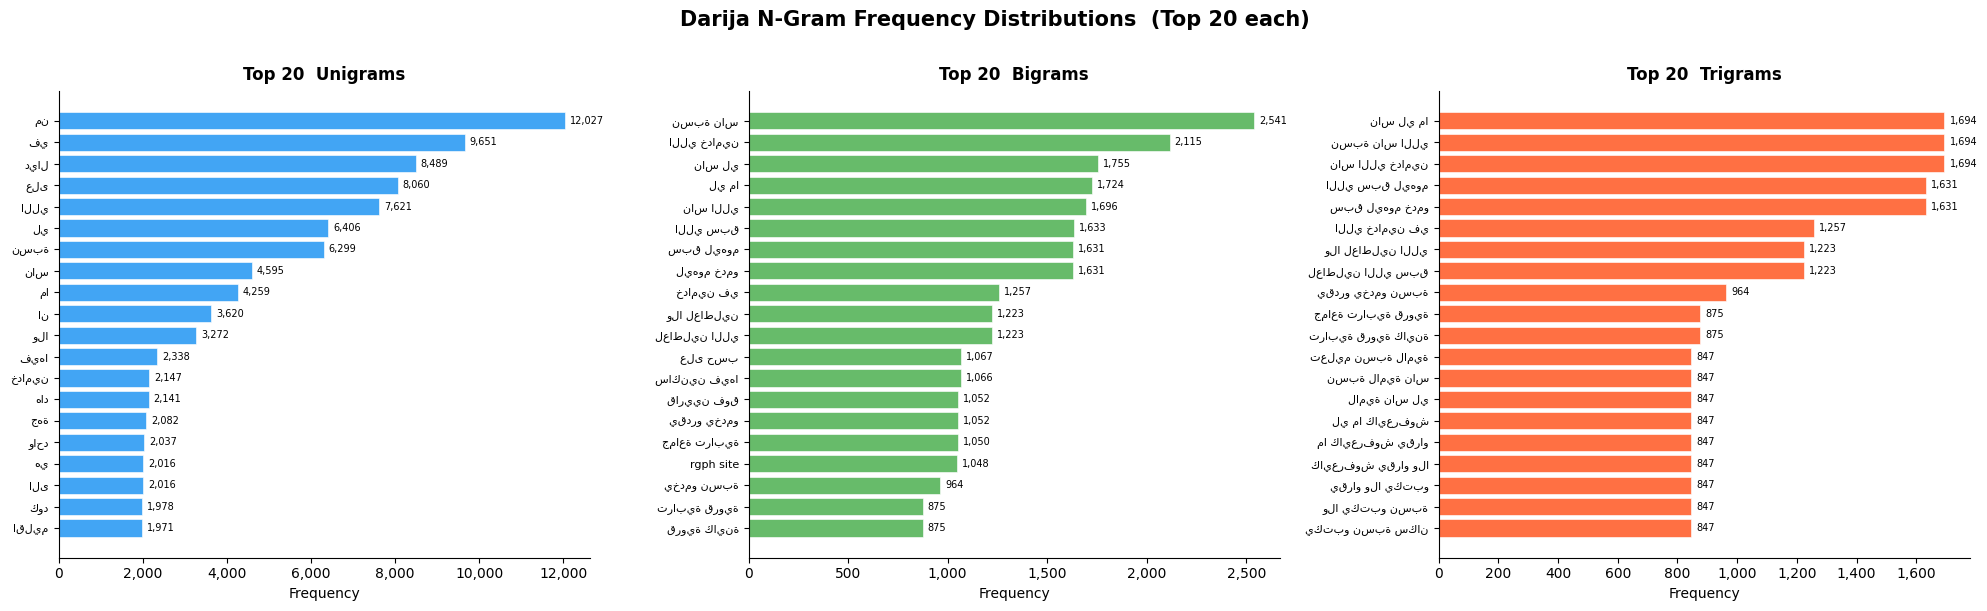

Chart saved to: C:\Users\Dell\Desktop\outputs\ngram_frequencies.png


In [38]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Darija N-Gram Frequency Distributions  (Top 20 each)",
    fontsize=15, fontweight='bold', y=1.01
)

plot_specs = [
    (unigram_counts, "Unigrams",  "#2196F3"),
    (bigram_counts,  "Bigrams",   "#4CAF50"),
    (trigram_counts, "Trigrams",  "#FF5722"),
]

for ax, (counter, title, color) in zip(axes, plot_specs):
    top    = counter.most_common(20)
    labels = [' '.join(k) if isinstance(k, tuple) else k  for k, _ in top]
    counts = [v for _, v in top]

    bars = ax.barh(range(len(labels)), counts,
                   color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"Top 20  {title}", fontweight='bold', pad=8)
    ax.set_xlabel("Frequency")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_width() + max(counts) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va='center', ha='left', fontsize=7
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

out_img = os.path.join(OUTPUT_DIR, "ngram_frequencies.png")
plt.savefig(out_img, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to: {out_img}")